# F3NinaC — Precursores e lags: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaC`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook testa antecedência física: em vez de correlacionar toda a série sem considerar o ciclo, relaciona cada variável na semana emissora t−lag ao estado do La Niña na semana receptora t, separadamente em cada fase.

## 2. Pergunta científica

Quais variáveis antecedem cada período e em quantas semanas?

## 3. Hipótese específica

Variáveis associadas à recarga oceânica e ao acoplamento vento-oceano antecedem mudanças do La Niña por lags positivos e com direção física coerente, mas o conjunto e o lag dominante podem variar entre gênese, crescimento, pico e decaimento.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

A varredura de lags usa pares condicionados pela fase emissora, número efetivo de graus de liberdade sob AR(1) e BH-FDR dentro da família declarada. O evento permanece a unidade de suporte; o maior |r| só é selecionado depois do controle de multiplicidade.

## 5. Metodologia

Correlação defasada condicionada pela fase na semana emissora t−lag, N efetivo AR(1), BH-FDR e unidade independente evento.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- varredura completa variável × fase × lag com r, N efetivo, p e q.
- melhor lag significativo de cada precursor e fase.
- tabela que conserva também os resultados nulos após FDR.

- figuras públicas iniciadas por `FigF3NinaC`;
- tabelas públicas iniciadas por `TabF3NinaC`;
- primeiro par reservado: `FigF3NinaC1` ↔ `TabF3NinaC1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Jin, F.-F. (1997). An Equatorial Ocean Recharge Paradigm for ENSO. Journal of the Atmospheric Sciences, 54, 811–829.
2. Meinen, C. S.; McPhaden, M. J. (2000). Observations of Warm Water Volume Changes in the Equatorial Pacific. Journal of Climate, 13, 3551–3559.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaC'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaC",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaC',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,melhores lags FDR,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,16312


## Resultados

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaC,1,fase3_nina,FigF3NinaC1,TabF3NinaC1,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,2e956b9dfbd69f5c068ae33107490cc94bbcc1b5b3e9f7...,c51682b955563d511e9d664758254c030fe2b82babe33d...,20260714T202702Z_5538a635


,tipo,fase,variavel,variavel_alvo,n_precursores_candidatos,aliases_alvo_excluidos,precursor_screening_policy,lag_semanas,r_pearson,n_pares,...,evaluation_mode,q_fdr_bh,significativo_fdr,field_p_simes,campo_significativo,field_test_method,field_test_assumption,rank_abs_r_na_familia,selection_rule,lag_selected_after_fdr
12,la_nina,crescimento,mslp_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,16,-0.272871,235,...,diagnostico_retrospectivo_inferencial,0.049801,True,0.000705,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,440.0,max_abs_r_entre_lags_significativos_fdr,True
2,la_nina,genese,mslp_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,9,-0.308658,256,...,diagnostico_retrospectivo_inferencial,0.008873,True,0.000077,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,578.0,max_abs_r_entre_lags_significativos_fdr,True
17,la_nina,crescimento,u200_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,1,-0.326514,235,...,diagnostico_retrospectivo_inferencial,0.016952,True,0.000705,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,248.0,max_abs_r_entre_lags_significativos_fdr,True
23,la_nina,decaimento,u10_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,42,-0.343652,294,...,diagnostico_retrospectivo_inferencial,0.015802,True,0.014061,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,139.0,max_abs_r_entre_lags_significativos_fdr,True
25,la_nina,decaimento,sshf_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.352072,294,...,diagnostico_retrospectivo_inferencial,0.016099,True,0.014061,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,130.0,max_abs_r_entre_lags_significativos_fdr,True
24,la_nina,decaimento,tcwv_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.376729,294,...,diagnostico_retrospectivo_inferencial,0.016842,True,0.014061,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,108.0,max_abs_r_entre_lags_significativos_fdr,True
22,la_nina,decaimento,tau_x_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,42,-0.383162,294,...,diagnostico_retrospectivo_inferencial,0.014061,True,0.014061,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,104.0,max_abs_r_entre_lags_significativos_fdr,True
18,la_nina,crescimento,omega850_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,25,-0.410169,235,...,diagnostico_retrospectivo_inferencial,0.049844,True,0.000705,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,105.0,max_abs_r_entre_lags_significativos_fdr,True
14,la_nina,crescimento,sshf_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.416998,235,...,diagnostico_retrospectivo_inferencial,0.005817,True,0.000705,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,98.0,max_abs_r_entre_lags_significativos_fdr,True
16,la_nina,crescimento,u850_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,1,0.476594,235,...,diagnostico_retrospectivo_inferencial,0.000705,True,0.000705,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,35.0,max_abs_r_entre_lags_significativos_fdr,True


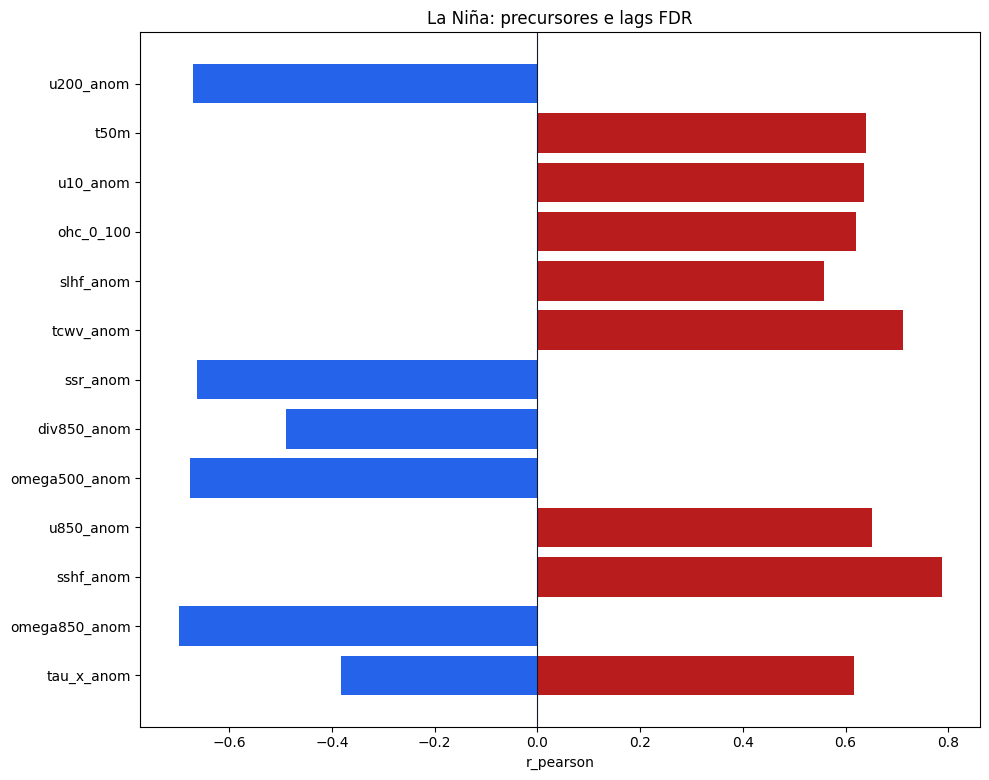

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

## Figuras para verificação rápida

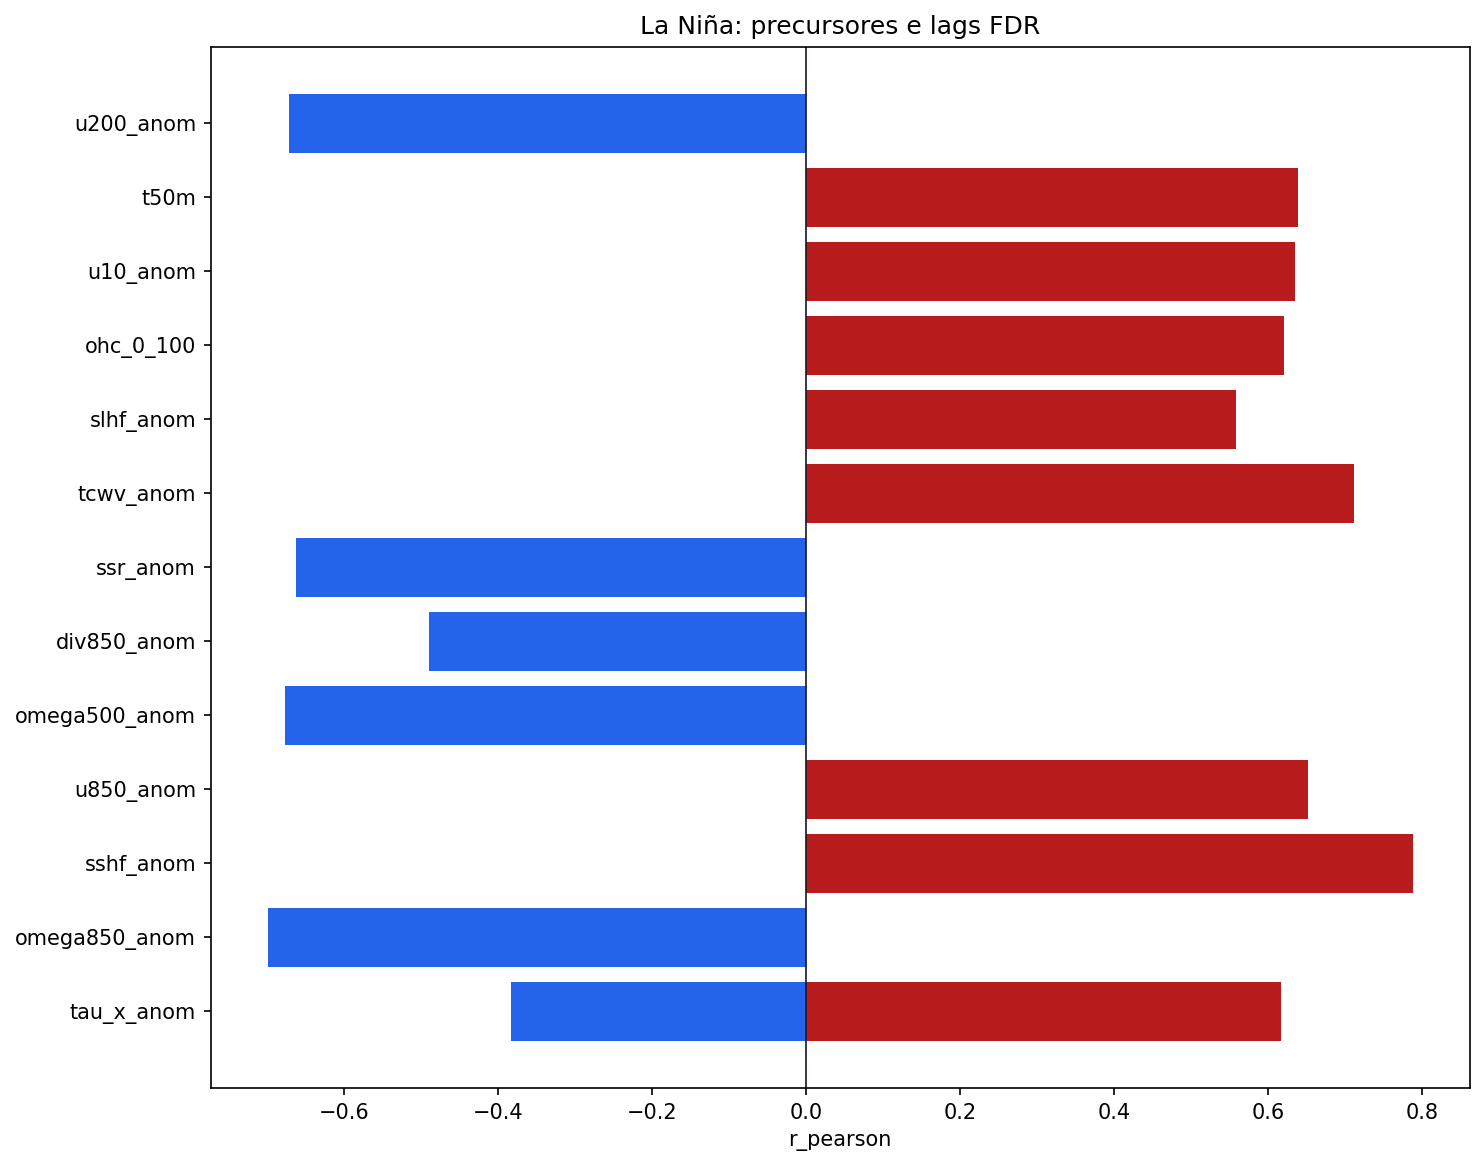

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- A tabela auditada contém 26 linhas para La Niña.
- A leitura mantém eventos independentes separados e não soma semanas como novas réplicas.

Limitações:
- A figura resume a tabela publicada; consulte a tabela completa e seu manifesto antes de interpretar valores individuais.
- Resultados negativos ou tabelas vazias são preservados e não são convertidos em falha técnica.
